In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error,mean_squared_error, r2_score)


from catboost import CatBoostRegressor

In [2]:
df = pd.read_csv("core_upscaled_dataset_long.csv")

print(df.shape)
df.head()

(250000, 8)


,Curve_ID,Sw,Core_Pc,Upscaled_Pc,Core_Porosity,Core_Permeability_mD,Reservoir_Porosity,Reservoir_Permeability_mD
0,1.0,0.150000,108.955000,495.118440,0.1624,2940.067,0.283,248.104
1,1.0,0.166327,108.955000,495.118440,0.1624,2940.067,0.283,248.104
2,1.0,0.182653,87.204365,396.278179,0.1624,2940.067,0.283,248.104
3,1.0,0.198980,67.602554,307.202707,0.1624,2940.067,0.283,248.104
4,1.0,0.215306,61.304966,278.584911,0.1624,2940.067,0.283,248.104


In [3]:
df.isna().sum()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
df = df.drop_duplicates()
print(df.shape)

(250000, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Curve_ID                   250000 non-null  float64
 1   Sw                         250000 non-null  float64
 2   Core_Pc                    250000 non-null  float64
 3   Upscaled_Pc                250000 non-null  float64
 4   Core_Porosity              250000 non-null  float64
 5   Core_Permeability_mD       250000 non-null  float64
 6   Reservoir_Porosity         250000 non-null  float64
 7   Reservoir_Permeability_mD  250000 non-null  float64
dtypes: float64(8)
memory usage: 15.3 MB


In [5]:
df.describe()

,Curve_ID,Sw,Core_Pc,Upscaled_Pc,Core_Porosity,Core_Permeability_mD,Reservoir_Porosity,Reservoir_Permeability_mD
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,2500.500000,0.550000,65.649833,202.536066,0.190918,439.869003,0.224460,1094.825807
std,1443.378531,0.235607,92.556063,853.680324,0.062811,936.282405,0.072267,2039.408405
min,1.000000,0.150000,1.981000,0.016214,0.080000,0.100000,0.100000,1.000000
25%,1250.750000,0.345918,23.603783,4.155295,0.136700,1.613250,0.161675,10.106750
50%,2500.500000,0.550000,44.485034,20.215891,0.192600,23.842500,0.224700,109.520500
75%,3750.250000,0.754082,68.570610,102.101825,0.244300,318.101750,0.287700,1092.174000
max,5000.000000,0.950000,1585.722000,48020.606310,0.299800,5005.102000,0.349900,9987.776000


In [4]:
df["Scaling_Factor"] = np.sqrt((df["Core_Permeability_mD"] /df["Core_Porosity"]) /(df["Reservoir_Permeability_mD"] /df["Reservoir_Porosity"]))
df.head()

,Curve_ID,Sw,Core_Pc,Upscaled_Pc,Core_Porosity,Core_Permeability_mD,Reservoir_Porosity,Reservoir_Permeability_mD,Scaling_Factor
0,1.0,0.150000,108.955000,495.118440,0.1624,2940.067,0.283,248.104,4.544247
1,1.0,0.166327,108.955000,495.118440,0.1624,2940.067,0.283,248.104,4.544247
2,1.0,0.182653,87.204365,396.278179,0.1624,2940.067,0.283,248.104,4.544247
3,1.0,0.198980,67.602554,307.202707,0.1624,2940.067,0.283,248.104,4.544247
4,1.0,0.215306,61.304966,278.584911,0.1624,2940.067,0.283,248.104,4.544247


In [5]:
df["Log_Scaling"] = np.log(df["Scaling_Factor"])
df.head()

,Curve_ID,Sw,Core_Pc,Upscaled_Pc,Core_Porosity,Core_Permeability_mD,Reservoir_Porosity,Reservoir_Permeability_mD,Scaling_Factor,Log_Scaling
0,1.0,0.150000,108.955000,495.118440,0.1624,2940.067,0.283,248.104,4.544247,1.513862
1,1.0,0.166327,108.955000,495.118440,0.1624,2940.067,0.283,248.104,4.544247,1.513862
2,1.0,0.182653,87.204365,396.278179,0.1624,2940.067,0.283,248.104,4.544247,1.513862
3,1.0,0.198980,67.602554,307.202707,0.1624,2940.067,0.283,248.104,4.544247,1.513862
4,1.0,0.215306,61.304966,278.584911,0.1624,2940.067,0.283,248.104,4.544247,1.513862


In [9]:
df["Scaling_Factor"].describe()


count    250000.000000
mean          3.082899
std           7.616158
min           0.002279
25%           0.113981
50%           0.498220
75%           2.211642
max          94.398894
Name: Scaling_Factor, dtype: float64

In [10]:
df["Log_Scaling"].describe()

count    250000.000000
mean         -0.678546
std           2.054107
min          -6.084041
25%          -2.171726
50%          -0.696716
75%           0.793735
max           4.547529
Name: Log_Scaling, dtype: float64

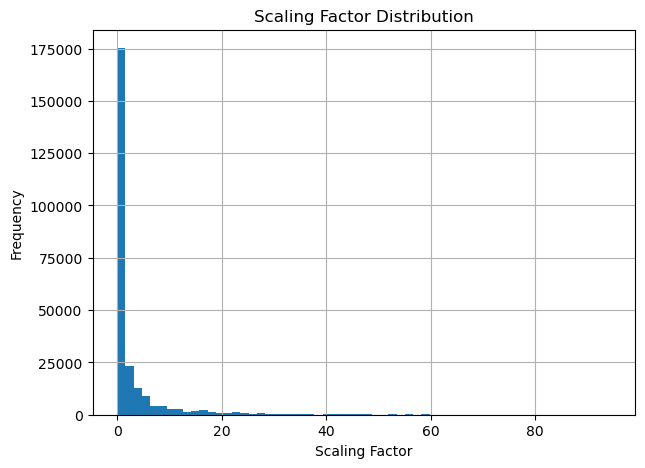

In [12]:
plt.figure(figsize=(7,5))
plt.hist(df["Scaling_Factor"],bins=60)
plt.xlabel("Scaling Factor")
plt.ylabel("Frequency")
plt.title("Scaling Factor Distribution")
plt.grid(True)
plt.show()

In [14]:
X = []
y = []

for curve_id, group in df.groupby("Curve_ID"):
    
    group = group.sort_values("Sw")
    core_pc = group["Core_Pc"].values.astype(float)
    core_pc_norm = core_pc / core_pc[0]
    phi_core = group["Core_Porosity"].iloc[0]
    k_core = group["Core_Permeability_mD"].iloc[0]
    phi_res = group["Reservoir_Porosity"].iloc[0]
    k_res = group["Reservoir_Permeability_mD"].iloc[0]
    log_scale = group["Log_Scaling"].iloc[0]
    features = np.concatenate([core_pc_norm, [phi_core,k_core,phi_res,k_res]])
    X.append(features)
    y.append(log_scale)

X = np.array(X)
y = np.array(y)
print("X shape is :", X.shape)
print("y shape is :", y.shape)

X shape is : (5000, 54)
y shape is : (5000,)


In [15]:
curve_ids = np.array(sorted(df["Curve_ID"].unique()))
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(X,y,curve_ids,test_size=0.20,random_state=42)

In [16]:
cat_model = CatBoostRegressor(iterations=1000, learning_rate=0.03,depth=8,loss_function="RMSE",eval_metric="RMSE", random_seed=42,verbose=100)
cat_model.fit(X_train,y_train, eval_set=(X_test, y_test),use_best_model=True)

0:	learn: 2.0057543	test: 1.9836321	best: 1.9836321 (0)	total: 192ms	remaining: 3m 11s
100:	learn: 0.2293555	test: 0.2393284	best: 0.2393284 (100)	total: 2.71s	remaining: 24.1s
200:	learn: 0.0659045	test: 0.0827755	best: 0.0827755 (200)	total: 4.37s	remaining: 17.4s
300:	learn: 0.0477936	test: 0.0654385	best: 0.0654385 (300)	total: 6.05s	remaining: 14s
400:	learn: 0.0400935	test: 0.0585556	best: 0.0585556 (400)	total: 7.72s	remaining: 11.5s
500:	learn: 0.0345345	test: 0.0539756	best: 0.0539756 (500)	total: 9.38s	remaining: 9.35s
600:	learn: 0.0305941	test: 0.0510880	best: 0.0510880 (600)	total: 11.1s	remaining: 7.34s
700:	learn: 0.0276440	test: 0.0493092	best: 0.0493092 (700)	total: 12.7s	remaining: 5.43s
800:	learn: 0.0252772	test: 0.0479946	best: 0.0479946 (800)	total: 14.4s	remaining: 3.58s
900:	learn: 0.0232739	test: 0.0469435	best: 0.0469435 (900)	total: 16.1s	remaining: 1.77s
999:	learn: 0.0216271	test: 0.0461080	best: 0.0461080 (999)	total: 17.7s	remaining: 0us

bestTest = 0.046

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [17]:
cat_pred_log = cat_model.predict(X_test)
cat_true = np.exp(y_test)
cat_pred = np.exp(cat_pred_log)

In [18]:
mae = mean_absolute_error(cat_true, cat_pred)
rmse = np.sqrt(mean_squared_error(cat_true,cat_pred))
r2 = r2_score(cat_true,cat_pred)
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

MAE : 0.0943
RMSE: 0.4623
R²  : 0.9942


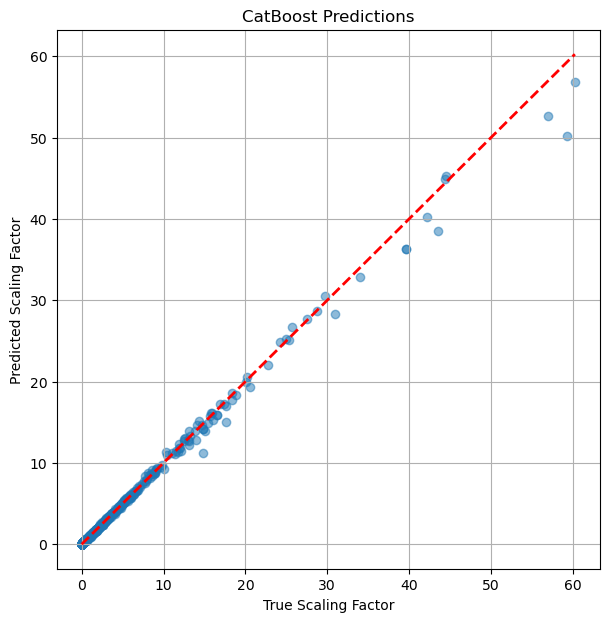

In [19]:
plt.figure(figsize=(7,7))
plt.scatter(cat_true,cat_pred,alpha=0.5)
xmin = cat_true.min()
xmax = cat_true.max()
plt.plot([xmin, xmax],[xmin, xmax],"r--",linewidth=2)
plt.xlabel("True Scaling Factor")
plt.ylabel("Predicted Scaling Factor")
plt.title("CatBoost Predictions")
plt.grid(True)
plt.show()

In [20]:
cat_model.save_model("ScalingFactorCatBoost.cbm")

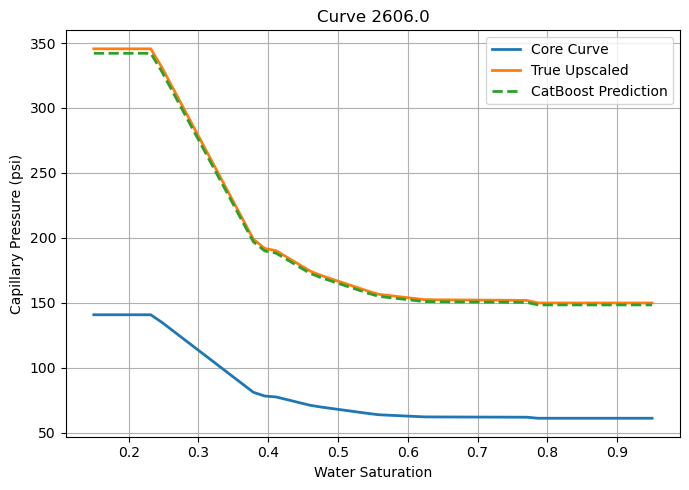

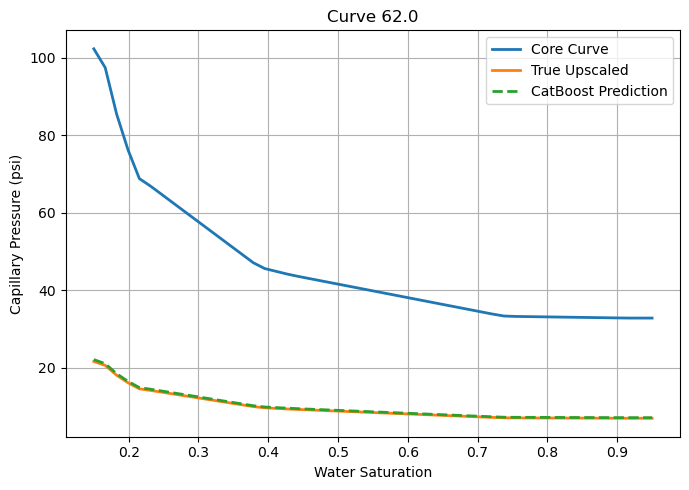

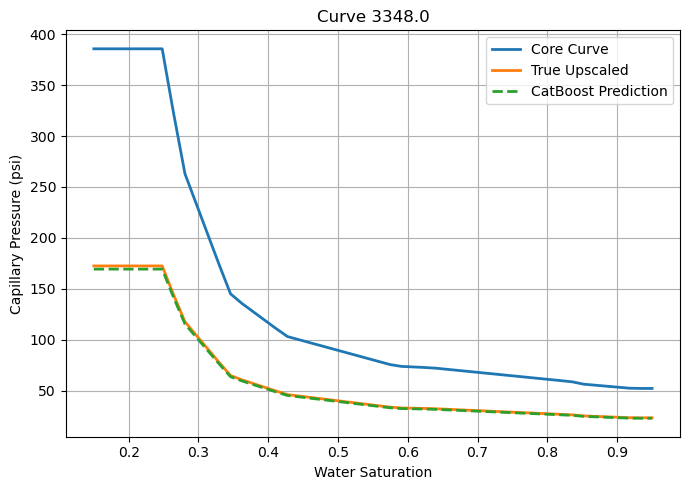

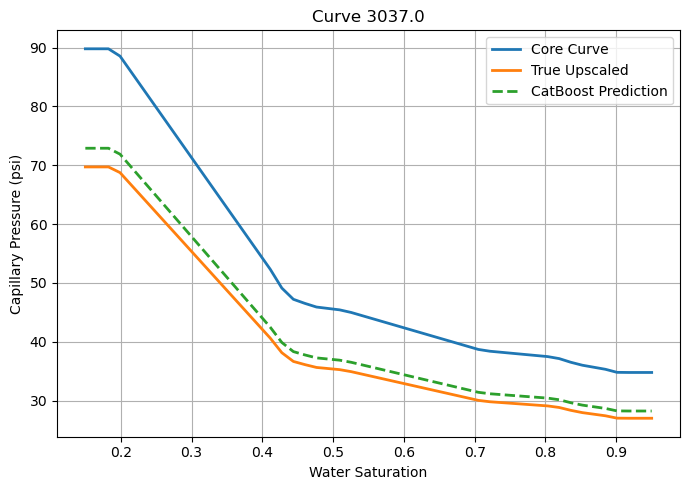

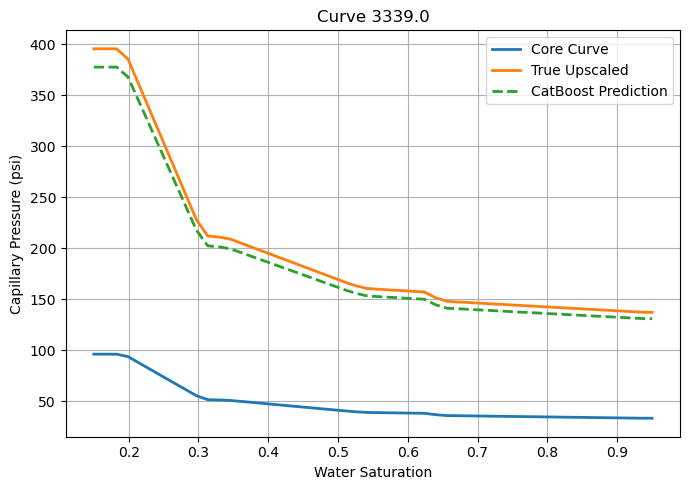

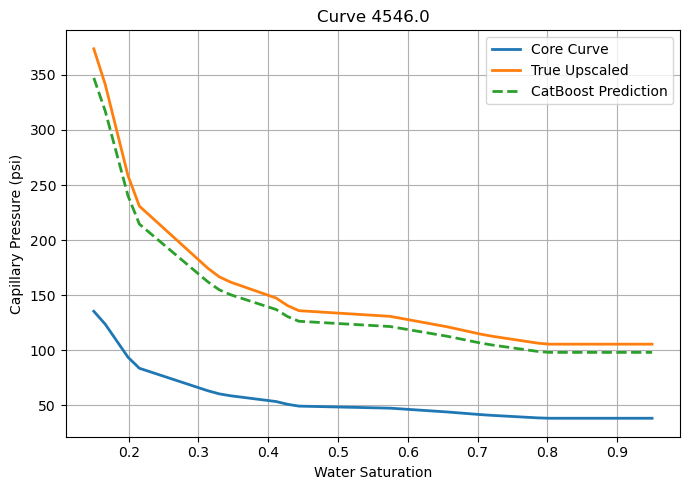

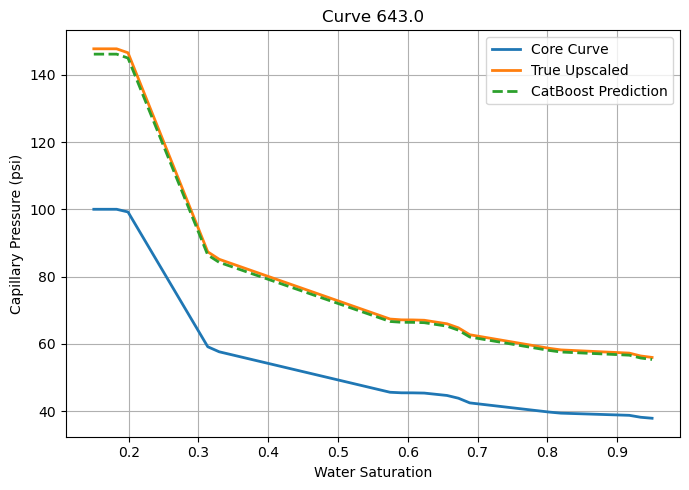

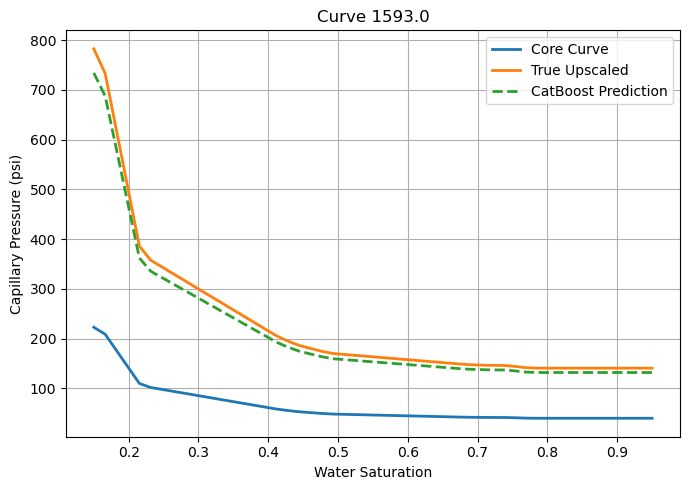

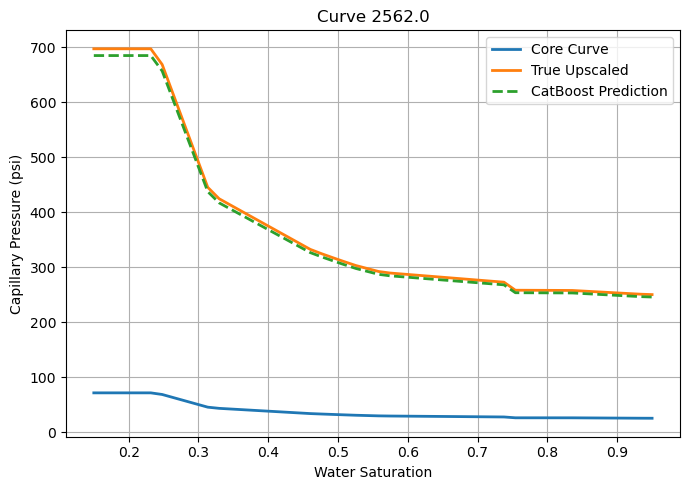

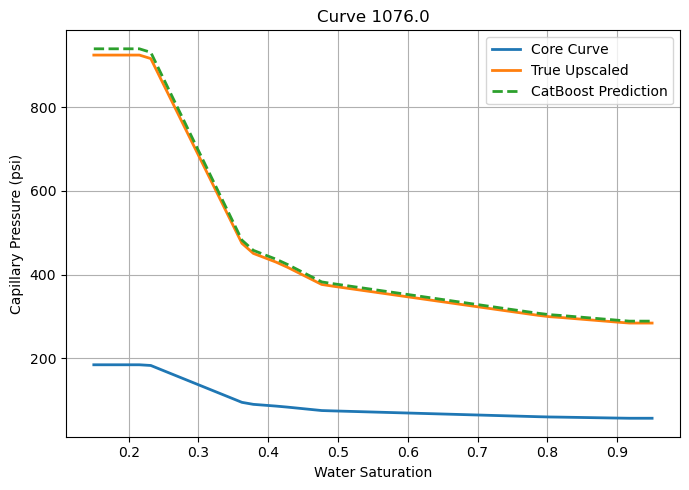

In [21]:
samples = np.random.choice(len(X_test), 10, replace=False)
for i in samples:

    curve = df[df["Curve_ID"] == id_test[i]].sort_values("Sw")
    sw = curve["Sw"].values
    core_curve = curve["Core_Pc"].values
    true_curve = curve["Upscaled_Pc"].values
    cat_curve = core_curve * cat_pred[i]
    plt.figure(figsize=(7,5))

    plt.plot(sw,core_curve,linewidth=2,label="Core Curve")

    plt.plot(sw,true_curve,linewidth=2,label="True Upscaled")

    plt.plot(sw,cat_curve,"--",linewidth=2,label="CatBoost Prediction")

    plt.xlabel("Water Saturation")
    plt.ylabel("Capillary Pressure (psi)")
    plt.title(f"Curve {id_test[i]}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()